In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/dataprofessor/data/master/delaney_solubility_with_descriptors.csv')
df

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
0,2.59540,167.850,0.0,0.000000,-2.180
1,2.37650,133.405,0.0,0.000000,-2.000
2,2.59380,167.850,1.0,0.000000,-1.740
3,2.02890,133.405,1.0,0.000000,-1.480
4,2.91890,187.375,1.0,0.000000,-3.040
...,...,...,...,...,...
1139,1.98820,287.343,8.0,0.000000,1.144
1140,3.42130,286.114,2.0,0.333333,-4.925
1141,3.60960,308.333,4.0,0.695652,-3.893
1142,2.56214,354.815,3.0,0.521739,-3.790


In [4]:
df.corr()['logS']

MolLogP              -0.827959
MolWt                -0.637324
NumRotatableBonds    -0.238508
AromaticProportion   -0.268108
logS                  1.000000
Name: logS, dtype: float64

In [7]:
# data seperation x and y
y = df['logS']
y

0      -2.180
1      -2.000
2      -1.740
3      -1.480
4      -3.040
        ...  
1139    1.144
1140   -4.925
1141   -3.893
1142   -3.790
1143   -2.581
Name: logS, Length: 1144, dtype: float64

In [9]:
x = df.drop('logS', axis=1)
x

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
0,2.59540,167.850,0.0,0.000000
1,2.37650,133.405,0.0,0.000000
2,2.59380,167.850,1.0,0.000000
3,2.02890,133.405,1.0,0.000000
4,2.91890,187.375,1.0,0.000000
...,...,...,...,...
1139,1.98820,287.343,8.0,0.000000
1140,3.42130,286.114,2.0,0.333333
1141,3.60960,308.333,4.0,0.695652
1142,2.56214,354.815,3.0,0.521739


In [11]:
# seperate data into 2 sets, for training and test 80:20
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=100)

In [12]:
#915 rows = 80% from the whole data to be fitted to train the model
x_train

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
107,3.14280,112.216,5.0,0.000000
378,-2.07850,142.070,0.0,0.000000
529,-0.47730,168.152,0.0,0.000000
546,-0.86740,154.125,0.0,0.000000
320,1.62150,100.161,2.0,0.000000
...,...,...,...,...
802,3.00254,250.301,1.0,0.842105
53,2.13860,82.146,3.0,0.000000
350,5.76304,256.348,0.0,0.900000
79,3.89960,186.339,10.0,0.000000


In [13]:
#229 rows the remaining 20% to test model prediction
x_test

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
822,2.91000,172.268,7.0,0.000000
118,7.27400,360.882,1.0,0.666667
347,1.94040,145.161,0.0,0.909091
1123,1.98640,119.378,0.0,0.000000
924,1.70062,108.140,0.0,0.750000
...,...,...,...,...
1114,1.76210,478.513,4.0,0.000000
427,6.32820,276.338,0.0,1.000000
711,0.04430,218.205,5.0,0.000000
4,2.91890,187.375,1.0,0.000000


In [14]:
#building the model, (Using Linear Regression model)
from sklearn.linear_model import LinearRegression

#training the model by fitting the 80% of the earlier seperated train data
lr = LinearRegression()
lr.fit(x_train, y_train)


LinearRegression()

In [15]:
# Testing the model to make prediction

y_lr_train_pred = lr.predict(x_train)
y_lr_test_pred = lr.predict(x_test)

In [16]:
# Evaluate the LR model peformance with MSE
from sklearn.metrics import mean_squared_error, r2_score

lr_train_mse = mean_squared_error(y_train, y_lr_train_pred)

#calculate the squared correlation coeficient
lr_train_r2 = r2_score(y_train, y_lr_train_pred)

# Repeat the same process for the test result

lr_test_mse = mean_squared_error(y_test, y_lr_test_pred)

lr_test_r2 = r2_score(y_test, y_lr_test_pred)

In [17]:
lr_train_mse

1.007536295109369

In [18]:
lr_train_r2

0.7645051774663391

In [19]:
lr_test_mse

1.0206953660861033

In [20]:
lr_test_r2

0.7891616188563282

In [26]:
# Arranging the results to DF for easier viewing
lr_results = pd.DataFrame(['Linear Regression', lr_train_mse, lr_train_r2, lr_test_mse, lr_test_r2]).transpose()
lr_results.columns = ['Method','Training MSE', 'Training r2', 'Test MSE', 'Test r2']

In [27]:
lr_results

,Method,Training MSE,Training r2,Test MSE,Test r2
0,Linear Regression,1.007536,0.764505,1.020695,0.789162


In [28]:
# Building Random Forest (regressor) model
from sklearn.ensemble import RandomForestRegressor

In [29]:
# Setting parameters with same random state value as LR model
rf = RandomForestRegressor(max_depth=2, random_state=100)
# Training the RF model with train set (80%)
rf.fit(x_train, y_train)

RandomForestRegressor(max_depth=2, random_state=100)

In [31]:
# Testing RF model to make prediction
y_rf_train_pred = rf.predict(x_train)
y_rf_test_pred = rf.predict(x_test)

In [32]:
# Evaluate the model RF peformance with MSE

rf_train_mse = mean_squared_error(y_train, y_rf_train_pred)

#calculate the squared correlation coeficient
rf_train_r2 = r2_score(y_train, y_rf_train_pred)

# Repeat the same process for the test result

rf_test_mse = mean_squared_error(y_test, y_rf_test_pred)

rf_test_r2 = r2_score(y_test, y_rf_test_pred)

In [34]:
# Arranging RF results into panda DF

rf_results = pd.DataFrame(['Random Forest', rf_train_mse, rf_train_r2, rf_test_mse, rf_test_r2]).transpose()
rf_results.columns = ['Method','Training MSE', 'Training r2', 'Test MSE', 'Test r2']
rf_results

,Method,Training MSE,Training r2,Test MSE,Test r2
0,Random Forest,1.028228,0.759669,1.407688,0.709223


In [35]:
# Combine both result table on 2 different model (concat)
df_models = pd.concat([lr_results, rf_results], axis=0)
df_models

,Method,Training MSE,Training r2,Test MSE,Test r2
0,Linear Regression,1.007536,0.764505,1.020695,0.789162
0,Random Forest,1.028228,0.759669,1.407688,0.709223


In [36]:
df_models.reset_index(drop=True)

,Method,Training MSE,Training r2,Test MSE,Test r2
0,Linear Regression,1.007536,0.764505,1.020695,0.789162
1,Random Forest,1.028228,0.759669,1.407688,0.709223


Text(0.5, 0, 'Experimental LogS')

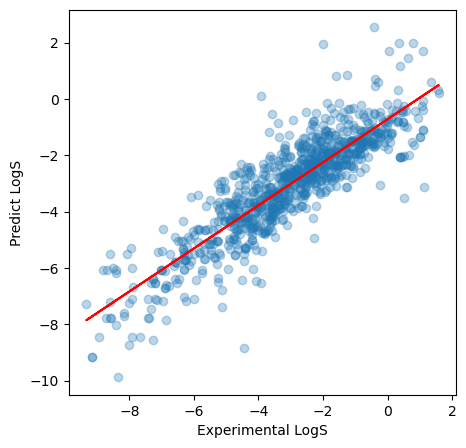

In [47]:
# Data Visualisation on the predictions
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(5,5))
plt.scatter(x=y_train, y=y_lr_train_pred, alpha=0.3)

z = np.polyfit(y_train, y_lr_train_pred, 1)
p = np.poly1d(z)

plt.plot(y_train, p(y_train), color='red')
plt.ylabel('Predict LogS')
plt.xlabel('Experimental LogS')